In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
df = pd.read_csv('rounded_hours_student_scores.csv')

In [132]:
df.head()

,Hours,Scores
0,1.1,41
1,1.2,40
2,1.4,38
3,1.5,39
4,1.6,36


# Linear Regression With Outliers

Text(0, 0.5, 'Scores')

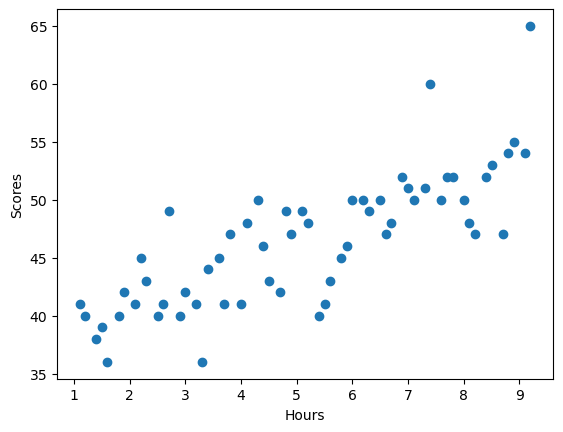

In [133]:
plt.scatter(df['Hours'],df['Scores'])
plt.xlabel('Hours')
plt.ylabel('Scores')

In [134]:
x = df['Hours'].values.reshape(-1,1)
y = df['Scores']

In [135]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [136]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [137]:
x_test

array([[6. ],
       [1.1],
       [7.6],
       [8.7],
       [4.3],
       [7.4],
       [5.9],
       [4.9],
       [7.8],
       [5.5],
       [1.2],
       [5.2]])

In [161]:
y_test

37    50
53    52
56    54
34    45
54    53
29    49
0     41
31    40
1     40
44    50
30    48
10    40
Name: Scores, dtype: int64

In [162]:
lr.predict(x_test[2].reshape(1,1))

array([51.80204194])

Text(0, 0.5, 'Scores')

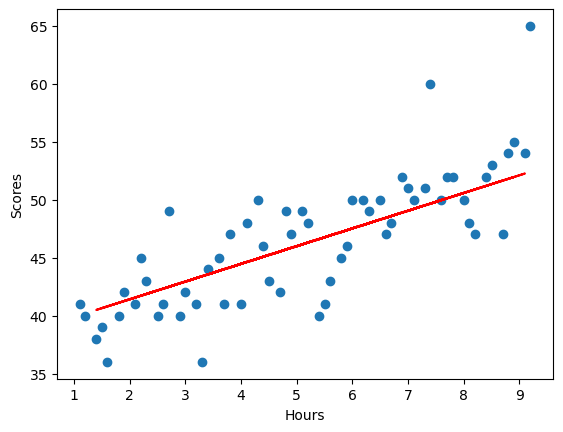

In [158]:
plt.scatter(df['Hours'],df['Scores'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('Hours')
plt.ylabel('Scores')

In [139]:
m = lr.coef_
m

array([1.97107599])

In [140]:
b = lr.intercept_
b

36.13000214902099

In [141]:
# y = mx + b

m * 6.0 + b

array([47.95645811])

# Finding Outliers

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_10512\3997767243.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Hours'])


<Axes: xlabel='Hours', ylabel='Density'>

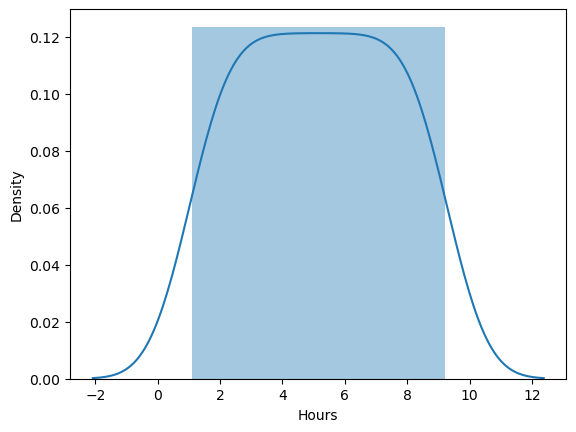

In [142]:
sns.distplot(df['Hours'])

In [143]:
highest = df['Scores'].quantile(0.97)
lowest = df['Scores'].quantile(0.03)

In [144]:
df[df['Scores'] > highest]

,Hours,Scores
46,7.4,60
59,9.2,65


In [145]:
df[df['Scores'] < lowest ]

,Hours,Scores
4,1.6,36
16,3.3,36


# Removing of Outliers

In [146]:
new_df = df[(df['Scores'] <= highest) & (df['Scores'] >= lowest)]

# Linear Regression Without outliers

Text(0, 0.5, 'Scores')

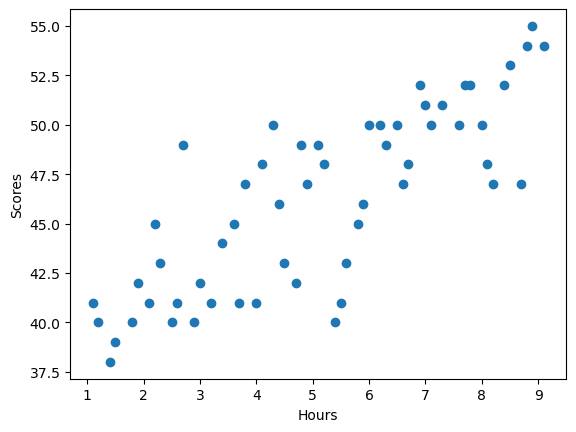

In [147]:
plt.scatter(new_df['Hours'],new_df['Scores'])
plt.xlabel('Hours')
plt.ylabel('Scores')

In [148]:
x = new_df['Hours'].values.reshape(-1,1)
y = new_df['Scores']

In [149]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [150]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [151]:
x_test

array([[6.2],
       [8.4],
       [8.8],
       [5.8],
       [8.5],
       [5.1],
       [1.1],
       [5.4],
       [1.2],
       [7.1],
       [5.2],
       [2.5]])

In [152]:
y_test

37    50
53    52
56    54
34    45
54    53
29    49
0     41
31    40
1     40
44    50
30    48
10    40
Name: Scores, dtype: int64

In [163]:
lr.predict(x_test[2].reshape(1,1))

array([51.80204194])

Text(0, 0.5, 'Scores')

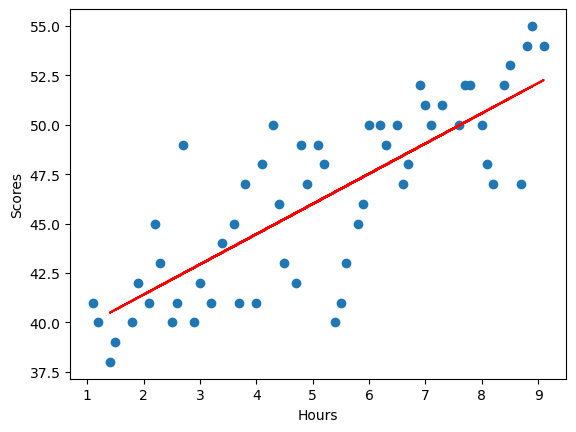

In [154]:
plt.scatter(new_df['Hours'],new_df['Scores'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('Hours')
plt.ylabel('Scores')

In [164]:
m = lr.coef_
m

array([1.52902937])

In [165]:
b = lr.intercept_
b

38.346583521835704

In [166]:
# y = mx + b

m * 6.2 + b

array([47.82656559])